In [ ]:
%pip install egglog graphviz

Initial EGraph:


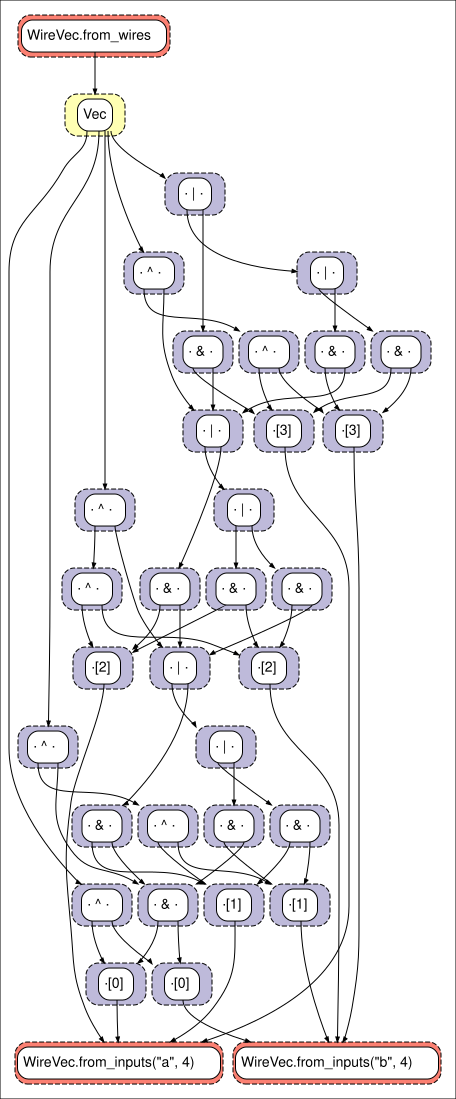

(rule ((= (WireVec_from_wires vec0) wv0)
       (= (WireVec_from_wires vec1) wv1)
       (= (WireVec_from_wires vec2) wv2)
       (= wv0 (WireVec_add i wv1 wv2))
       (= w2 (Wire___xor__ (Wire___xor__ w0 w1) (vec-get vec0 (- i 1))))
       (= w3 (Wire___or__ (Wire___or__ (Wire___and__ w0 w1) (Wire___and__ w1 (vec-get vec0 (- i 1)))) (Wire___and__ w0 (vec-get vec0 (- i 1))))))
      ((subsume (WireVec_add i wv1 wv2))
       (union (WireVec_add (+ i 1) (WireVec_from_wires (vec-push vec1 w0)) (WireVec_from_wires (vec-push vec2 w1))) (WireVec_from_wires (vec-push (vec-push (vec-pop vec0) w2) w3))))
         ): 3 matches
(rule ((= w2 (Wire___xor__ w0 w1))
       (= w3 (Wire___and__ w0 w1)))
      ((union (WireVec_add 2 (WireVec_from_wires (vec-of w0)) (WireVec_from_wires (vec-of w1))) (WireVec_from_wires (vec-of w2 w3))))
         ): 4 matches

EGraph after running the adder extraction rules:


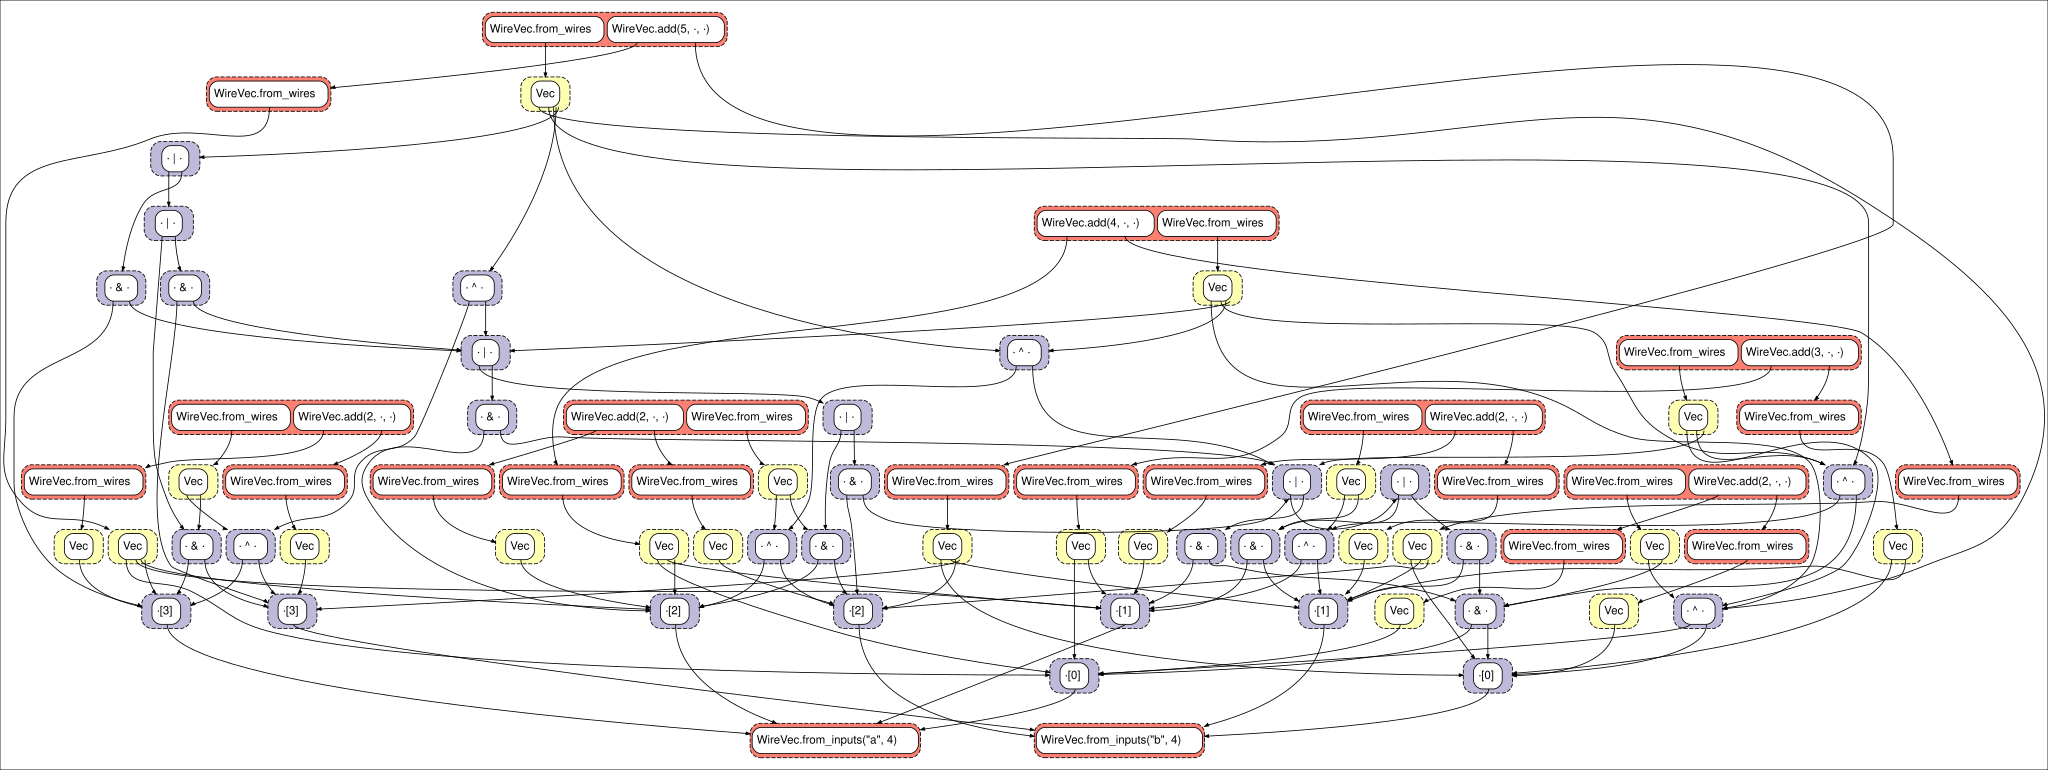

In [5]:
from __future__ import annotations
import egglog


class Wire(egglog.Expr):
    @classmethod
    def from_input(cls, name: egglog.StringLike) -> Wire: ...

    def __and__(self, other: Wire) -> Wire: ...

    def __or__(self, other: Wire) -> Wire: ...

    def __xor__(self, other: Wire) -> Wire: ...

    def __invert__(self) -> Wire: ...

class WireVec(egglog.Expr):
    @classmethod
    def from_inputs(cls, name: egglog.StringLike, width: egglog.i64Like) -> WireVec: ...

    @classmethod
    def from_wires(cls, wires: egglog.Vec[Wire]) -> WireVec: ...

    @classmethod
    def add(cls, out_width: egglog.i64Like, a: WireVec, b: WireVec) -> WireVec: ...

    @classmethod
    def mul(cls, out_width: egglog.i64Like, a: WireVec, b: WireVec) -> WireVec: ...

    def __getitem__(self, index: egglog.i64Like) -> Wire: ...   # this is necessary for indexing from_inputs


egraph = egglog.EGraph()
wv0, wv1, wv2 = egglog.vars_("wv0 wv1 wv2", WireVec)
w0, w1, w2, w3, w4, w5 = egglog.vars_("w0 w1 w2 w3 w4 w5", Wire)
vec0, vec1, vec2 = egglog.vars_("vec0 vec1 vec2", egglog.Vec[Wire])
i, j = egglog.vars_("i j", egglog.i64)

egraph.register(
    # Wire rules
    # egglog.rewrite(w0 & w1).to(w1 & w0),
    # egglog.rewrite(w0 | w1).to(w1 | w0),
    # egglog.rewrite(w0 ^ w1).to(w1 ^ w0),
    # egglog.rewrite(~~w0).to(w0),

    # WireVec rules
    # egglog.rewrite(WireVec.from_wires(vec0)[i]).to(vec0[i]),

    # Adder extraction rules
    egglog.rule(    # 1-bit adder
        egglog.eq(w2).to(w0 ^ w1),  # sum
        egglog.eq(w3).to(w0 & w1)   # carry
    ).then(
        egglog.union(
            WireVec.add(2, WireVec.from_wires(egglog.Vec(w0)), WireVec.from_wires(egglog.Vec(w1)))
        ).with_(WireVec.from_wires(egglog.Vec(w2, w3)))
    ),
    egglog.rule(    # (i+1)-bit adder from i-bit adder
        egglog.eq(WireVec.from_wires(vec0)).to(wv0),
        egglog.eq(WireVec.from_wires(vec1)).to(wv1),
        egglog.eq(WireVec.from_wires(vec2)).to(wv2),
        egglog.eq(wv0).to(WireVec.add(i, wv1, wv2)),
        egglog.eq(w2).to(w0 ^ w1 ^ vec0[i - 1]),                                 # sum
        egglog.eq(w3).to(((w0 & w1) | (w1 & vec0[i - 1]) | (w0 & vec0[i - 1])))   # carry
    ).then(
        egglog.subsume(WireVec.add(i, wv1, wv2)),
        egglog.union(
            WireVec.add(i + 1, WireVec.from_wires(vec1.push(w0)), WireVec.from_wires(vec2.push(w1)))
        ).with_(WireVec.from_wires(vec0.pop().push(w2).push(w3)))
    )
)

a = egraph.let("a", WireVec.from_inputs("a", 4))
b = egraph.let("b", WireVec.from_inputs("b", 4))

# 4-bit adder example, use logic gates to compute the sum and carry
sum0 = egraph.let("sum0", a[0] ^ b[0])
carry0 = egraph.let("carry0", a[0] & b[0])
sum1 = egraph.let("sum1", a[1] ^ b[1] ^ carry0)
carry1 = egraph.let("carry1", ((a[1] & b[1]) | (b[1] & carry0) | (a[1] & carry0)))
sum2 = egraph.let("sum2", a[2] ^ b[2] ^ carry1)
carry2 = egraph.let("carry2", ((a[2] & b[2]) | (b[2] & carry1) | (a[2] & carry1)))
sum3 = egraph.let("sum3", a[3] ^ b[3] ^ carry2)
carry3 = egraph.let("carry3", ((a[3] & b[3]) | (b[3] & carry2) | (a[3] & carry2)))
sum = egraph.let("sum", WireVec.from_wires(egglog.Vec(sum0, sum1, sum2, sum3, carry3)))

print("Initial EGraph:")
egraph.display(graphviz=True)

report = egraph.run(100)
for rule, cnt in report.num_matches_per_rule.items():
    print(f"{rule}: {cnt} matches")

egraph.check(egglog.eq(sum).to(WireVec.add(5,
    WireVec.from_wires(egglog.Vec(a[0], a[1], a[2], a[3])),
    WireVec.from_wires(egglog.Vec(b[0], b[1], b[2], b[3]))
)))

print("\nEGraph after running the adder extraction rules:")
egraph.display(graphviz=True)